In [1]:
import matplotlib as mpl
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np

import sys
import datetime

import sympy

import sigmf
from sigmf import SigMFFile
from sigmf.utils import get_data_type_str

In [2]:
def generate_zadoff_chu(N, r):
    """
    Generate a Zadoff-Chu sequence of length N with root index r.
    
    Parameters:
        N (int): Length of the sequence (must be prime for ideal properties).
        r (int): Root index (must be relatively prime to N).
        
    Returns:
        np.ndarray: Complex Zadoff-Chu sequence.
    """
    if np.gcd(N, r) != 1:
        raise ValueError("Root index r must be coprime with N for good properties.")

    # Generate the sequence indices
    n = np.arange(N);
    
    # Compute the Zadoff-Chu sequence
    zc_seq = np.exp(-1j * np.pi * r * n * (n + 1) / N)
    
    return zc_seq

In [3]:
sample_rate = 250e3

# duration = 10
duration = 6

repeats = 1

number_of_samples = int(duration * sample_rate)

fs = sample_rate

print("Samples:",number_of_samples)

Samples: 1500000


In [4]:
path = "/Users/telkamp/data/eme/tx_signals/"
name = "tbd"
data_file = path + name + ".sigmf-data"
meta_file = path + name + ".sigmf-meta"
print(data_file)

/Users/telkamp/data/eme/tx_signals/tbd.sigmf-data


In [5]:
# CW
number_of_samples = int(duration * sample_rate)
data = np.ones(number_of_samples, dtype=np.complex64)

freq_offset = 0
# data = data * np.transpose(
#     np.exp(-1j * 2 * np.pi * (-freq_offset / fs) * (np.arange(len(data))))
# )
name = "cw-fs"+str(int(sample_rate))+"-"+str(duration)+"sec"
data_file = path + name + ".sigmf-data"
meta_file = path + name + ".sigmf-meta"
print(data_file)

/Users/telkamp/data/eme/tx_signals/cw-fs250000-6sec.sigmf-data


In [6]:
# ***** Zadoff-Chu *****

max_doppler = 10

zc_bw = int(50e3)
number_of_samples = int(duration*zc_bw)
zc_len = sympy.nextprime(number_of_samples)

min_q = 4*max_doppler*zc_len/zc_bw

q = sympy.nextprime(int(min_q+0.5))

print(zc_len)
print(number_of_samples)

data = generate_zadoff_chu(int(zc_len),q)[:number_of_samples]
data = np.repeat(data,int(duration*sample_rate/number_of_samples))

# repeated ZC
data = np.tile(data,repeats)

print(len(data))

name = "zadoff-chu-fs"+str(int(sample_rate))+"-fzc"+str(zc_bw)+"-l"+str(zc_len)+"-q"+str(q)+"-"+str(duration)+"sec-"+str(repeats)+"x"
data_file = path + name + ".sigmf-data"
meta_file = path + name + ".sigmf-meta"
print(data_file)

print("Minimal q:", 3*max_doppler*zc_len/zc_bw)
print("1st offset (Hz):", round(zc_bw*q/zc_len,2))

300007
300000
1500000
/Users/telkamp/data/eme/tx_signals/zadoff-chu-fs250000-fzc50000-l300007-q241-6sec-1x.sigmf-data
Minimal q: 180.0042
1st offset (Hz): 40.17


In [7]:
print(len(data))

1500000


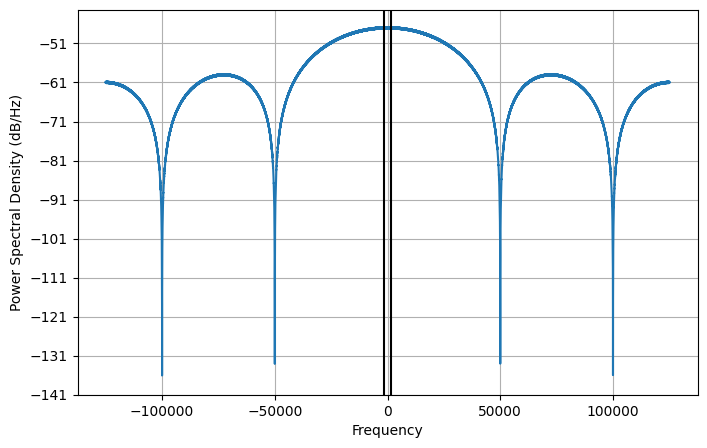

In [8]:
fig, ax0 = plt.subplots(figsize=(8, 5))
ax0.psd(data, Fs=fs, NFFT=64*1024);
ax0.axvline(-1.5e3, color='black')
ax0.axvline(1.5e3, color='black');
# ax0.set_xlim(-100e3,100e3)

In [9]:
# rescale and save as a complex int16 file:
data *= pow(2, 15)-1
data.astype(np.complex64).view(np.float32).astype(np.int16).tofile(data_file)

In [10]:
np.max(np.abs(data))

32767.000000000007

In [11]:
len(data)

1500000

In [12]:
# create the metadata
meta = SigMFFile(
    data_file=data_file, # extension is optional
    global_info = {
        SigMFFile.DATATYPE_KEY: 'ci16_le',
        SigMFFile.SAMPLE_RATE_KEY: sample_rate,
        SigMFFile.AUTHOR_KEY: 'Thomas Telkamp',
        SigMFFile.DESCRIPTION_KEY: name,
        SigMFFile.VERSION_KEY: sigmf.__version__,
        "vrt:tx_gain": 10,
    }
)

In [13]:
# create a capture key at time index 0
meta.add_capture(0, metadata={
    SigMFFile.FREQUENCY_KEY: 1299500000,
    SigMFFile.DATETIME_KEY: datetime.datetime.utcnow().isoformat()+'Z',
})

# write to disk
meta.tofile(meta_file) # extension is optional